Natural Language Processing (NLP)
===

___

Author: <u>*Virtsudo*</u>

Date: **May 2026**

## 0. Utils preparation

### 0.1 Imports and Plots

In [76]:
# imports
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from datasets import Dataset as HFDataset, DatasetDict as HFDatasetDict
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import DataCollatorForTokenClassification, Trainer
from sklearn.model_selection import train_test_split
from transformers import TrainingArguments
from matplotlib.colors import LogNorm
from transformers import AutoConfig
from collections import defaultdict
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import unicodedata
import torch
import glob
import gc
import re
import os

In [77]:
# file naming wrapper
def name_wrapper(text: str, fallback: str = "file", max_len: int = 255) -> str:
    cleaned = "".join(ch for ch in re.sub(r"\s+", "_", unicodedata.normalize("NFKC", text.lower()).strip()) if ch.isalnum() or ch in {"_", "-", "."}).rstrip(" .")
    if not cleaned: cleaned = fallback
    return cleaned[:max_len]

In [78]:
# plots
def plot_bar(title: str, items: dict, y: str = None):
    x = range(len(items.keys()))
    plt.figure(figsize=(8, 4))
    plt.bar(x, items.values(), width=0.5)
    plt.xticks(x, items.keys(), rotation=30, ha="right")
    if y is not None: plt.ylabel(y)
    plt.ylim(0, max(items.values()) * 1.15)
    plt.title(title)
    for i, v in enumerate(items.values()):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"../report/img/bar_{name_wrapper(title)}.png")
    plt.show()

def plot_bars(title: str, dict1: dict[str, float], dict2: dict[str, float], models: tuple[str, str], y: str = None, y_lim: int = None):
    tags: list[str] = sorted(set(dict1) | set(dict2))
    cat1 = np.array([float(dict1.get(t, 0)) for t in tags])
    cat2  = np.array([float(dict2.get(t, 0))  for t in tags])
    x = np.arange(len(tags))
    fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(tags)), 5))
    ax.bar(x - 0.2, cat1, width=0.4, label=models[0])
    ax.bar(x + 0.2, cat2,  width=0.4, label=models[1])
    if y_lim is not None:
        ax.set_ylim(0, y_lim)
        for i, v in enumerate(cat1):
            ax.text(i, v + 1, f"{v:.1f}%", ha="right", va="bottom", fontsize=8)
        for i, v in enumerate(cat2):
            ax.text(i, v + 1, f"{v:.1f}%", ha="left", va="bottom", fontsize=8)
    ax.set_title(title)
    if y is not None: ax.set_ylabel(y)
    ax.set_xticks(x)
    ax.set_xticklabels(tags, rotation=30, ha="right")

    ax.legend(loc='lower right', ncol=2)
    fig.tight_layout()
    plt.savefig(f"../report/img/bars_{name_wrapper(title)}.png")
    plt.show()

def plot_ecdf(title: str, values, x_label: str = None, x_lim: tuple[float, float] = None, y_lim: tuple[float, float] = None):
    x = np.sort(values)
    n = x.size
    y = np.arange(1, n + 1) / n
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, label="ECDF")
    if x_label is not None: plt.xlabel(x_label)
    plt.ylabel("ECDF")
    plt.title(title)
    if x_lim: plt.xlim(x_lim[0], x_lim[1])
    if y_lim: plt.ylim(y_lim[0], y_lim[1])
    plt.savefig(f"../report/img/ecdf_{name_wrapper(title)}.png")
    plt.show()

def plot_scatter_ratio(title: str, x: list, y: list):
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, s=8, alpha=0.4)
    plt.xlabel("Number of words per session")
    plt.ylabel("Number of tokens per session")
    plt.title(title)
    plt.savefig(f"../report/img/scatter_ratio_{name_wrapper(title)}.png")
    plt.show()

def plot_scatter_fp(title: str, x: list, y: list, count: list, top_k=4):
    x = np.array(x)
    y = np.array(y)
    count = np.array(count)
    sizes = 10 * np.log1p(count)
    sizes = np.clip(sizes, 5, 200)
    fig, ax = plt.subplots(figsize=(10, 5))
    sc = ax.scatter(x, y, s=sizes, c=count, alpha=0.6, edgecolors='none', norm=LogNorm(vmin=max(1, count.min()), vmax=count.max()))

    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='associated sessions')
    top_idx = np.argsort(count)[-top_k:]
    for n, idx in enumerate(top_idx, start=1):
        ax.annotate(str(n), (x[idx], y[idx]), xytext=(8, 8), textcoords="offset points", bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.3"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Date")
    ax.set_ylabel("ID Fingerprints")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"../report/img/scatter_fp_{name_wrapper(title)}.png")
    plt.show()

### 0.2 Reusable components

In [79]:
# define distribution tags compute function
def get_dist_tags(lbls, uts):
    cv = {k: 0 for k in uts}    # count vectorizer
    for l in lbls:
        for t in l:
            cv[t] += 1
    return cv

In [80]:
# define tag distribution per bash compute function
def dist_tags_per_bash_word(ssns: list, lbls: list, wrd: str):
    dtpb = dict()   # distribution tags per bash
    ssns = [i.split(' ') for i in ssns]     # sessions
    for s in range(len(ssns)):
        for t in range(len(ssns[s])):
            if ssns[s][t] == wrd:
                if lbls[s][t] in dtpb.keys():
                    dtpb[lbls[s][t]] += 1
                else:
                    dtpb[lbls[s][t]] = 1
    return dtpb

In [81]:
# define word tag pairs builder function
def get_words_tags_pair(df):
    wrds = [[s.split(' ')[i][:30] if len(s.split(' ')[i]) > 30 else s.split(' ')[i] for i in range(len(s.split(' ')))]for s in df['session'].to_list()]    # truncated
    tags = [t for t in df['label'].to_list()]
    assert len(wrds) == len(tags)  # check size of words and tags equality
    for w, t in zip(wrds, tags):
        assert len(w) == len(t)     # check size of words and tags equality per entry
    return wrds, tags

In [82]:
# define aligner function
def aligner(wrds, tags, tokenized, lbl2id):
    assert len(wrds) == len(tags)
    lbl = list()
    for i in range(len(wrds)):
        lbl_ids = list()
        wrd_ids = tokenized.word_ids(i)
        for p in range(len(wrd_ids)):
            if wrd_ids[p] is None:
                lbl_ids.append(-100)
            else:
                lbl_ids.append(lbl2id[tags[i][wrd_ids[p]]])
        lbl.append(lbl_ids)
    return lbl

In [83]:
# define compute_metrics function
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    flat_preds = preds.reshape(-1)
    flat_labels = labels.reshape(-1)

    mask = flat_labels != -100
    y_true = flat_labels[mask]
    y_pred = flat_preds[mask]

    token_accuracy = accuracy_score(y_true, y_pred)
    token_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    token_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    token_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

    fidelity = list()

    for i in range(len(preds)):
        mask_i = labels[i] != -100
        y_true_i = labels[i][mask_i]
        y_pred_i = preds[i][mask_i]
        fidelity.append(np.sum(y_true_i == y_pred_i) / len(y_true_i) if len(y_true_i) != 0 else 0)

    metrics = {
        "token_accuracy": token_accuracy,
        "token_precision": token_precision,
        "token_recall": token_recall,
        "token_f1": token_f1,
        'avg_fidelity': np.average(fidelity),
    }

    for class_id, f1 in enumerate(f1_per_class):
        metrics[f"f1_{id2label[class_id]}"] = f1

    return metrics

In [84]:
# define trainer init function
def get_trainer(model, tokenizer, training_args, train_dataset, val_dataset, data_collator, compute_metrics, lr: float = None)-> Trainer:
    if lr is not None: training_args.learning_rate = lr
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

In [85]:
# define words extraction function
def get_words(df):
    word_list = list()
    for s in df['session'].to_list():
        wrds = list()
        for i in range(len(s.split())):
            tokens = s.split()[i]
            if len(tokens) > 30:
                wrds.append(tokens[:30])
            else:
                wrds.append(tokens)
        word_list.append(wrds)
    return word_list

## 1. Dataset Characterization

### 1.1 Explore the labels

In [86]:
# read dataset
df_train = pd.read_json("../data/train.json")
df_test = pd.read_json("../data/test.json")
df_deploy = pd.read_csv("../data/cyberlab.csv")     # for inference

In [87]:
# extract sessions
train_sessions = df_train['session'].tolist()
test_sessions = df_test['session'].tolist()
total_sessions = train_sessions + test_sessions

In [88]:
# extract labels
train_labels = df_train["label"].tolist()
test_labels = df_test["label"].tolist()
total_labels = train_labels + test_labels

In [89]:
# extract unique tags
unique_tags = {tag for tags in total_labels for tag in tags}
print(f"Number of unique tags: {len(unique_tags)}\nUnique tags: {unique_tags}")

Number of unique tags: 7
Unique tags: {'Impact', 'Discovery', 'Persistence', 'Not Malicious Yet', 'Defense Evasion', 'Execution', 'Other'}


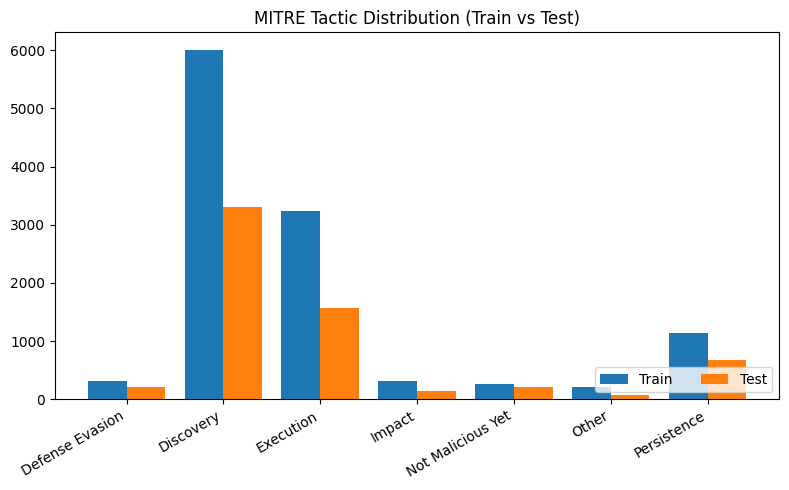

In [90]:
# distribution of each tag per train, test
train_dist_tags = get_dist_tags(train_labels, unique_tags)
test_dist_tags = get_dist_tags(test_labels, unique_tags)

# plot bar of tag distribution
plot_bars("MITRE Tactic Distribution (Train vs Test)", train_dist_tags, test_dist_tags, ("Train", "Test"))

Majority classes are `Discovery` and `Execution`, while other classes distributed near equally

### 1.2 Explore a single bash command

Number of tags assign to `echo` in training set: 6
Number of tags assign to `echo` in test set: 5


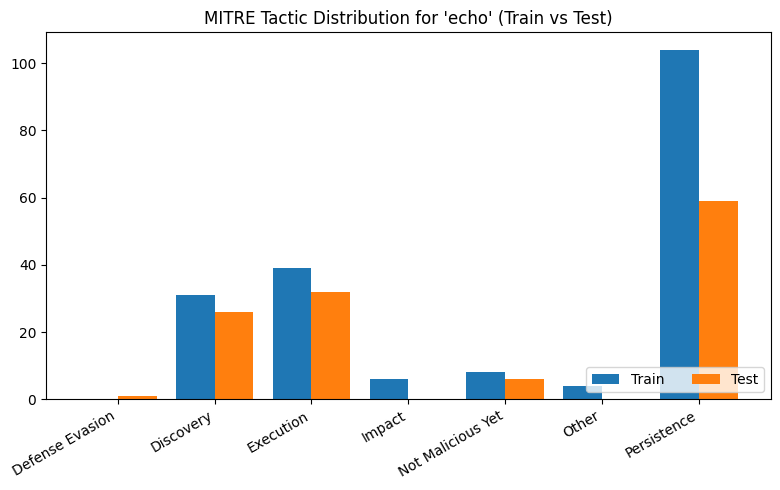

In [91]:
# explore 'echo' - bash word
train_dist_tags_echo = dist_tags_per_bash_word(train_sessions, train_labels, "echo")
test_dist_tags_echo = dist_tags_per_bash_word(test_sessions, test_labels, "echo")

print(f"Number of tags assign to `echo` in training set: {len(train_dist_tags_echo)}")
print(f"Number of tags assign to `echo` in test set: {len(test_dist_tags_echo)}")

# plot bar of tag distribution per 'echo'
plot_bars("MITRE Tactic Distribution for 'echo' (Train vs Test)", train_dist_tags_echo, test_dist_tags_echo, ("Train", "Test"))

In [92]:
# given tags example assigned to 'echo'
pers_example, exec_example = None, None

sessions = [i.split(' ') for i in total_sessions]
for i in range(len(sessions)):
    for j in range(len(sessions[i])):
        if sessions[i][j] == 'echo' and total_labels[i][j] == 'Persistence':
            pers_example = total_sessions[i]
        elif sessions[i][j] == 'echo' and total_labels[i][j] == 'Execution':
            exec_example = total_sessions[i]

print(f"Persistence example:\n{pers_example}\n\n")
print(f"Execution example:\n{exec_example}")


Persistence example:
cat /proc/cpuinfo | grep name | wc -l ; echo root:bFAy5nFET5hq | chpasswd | bash ; echo 321 > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk {print $4,$5,$6,$7,$8,$9;} ; free -m | grep Mem | awk {print $2 ,$3, $4, $5, $6, $7} ; which ls ; ls -lh $which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo root 123 > /tmp/up.txt ; rm -rf /var/tmp/dota* ; cat /var/tmp/.systemcache436621 ; echo 1 > /var/tmp/.systemcache436621 ; cat /var/tmp/.systemcache436621 ; sleep 15s && cd /var/tmp ; echo IyEvYmluL2Jhc2gKY2QgL3RtcAkKcm0gLXJmIC5zc2gKcm0gLXJmIC5tb3VudGZzCnJtIC1yZiAuWDEzLXVuaXgKcm0gLXJmIC5YMTctdW5peApta2RpciAuWDE3LXVuaXgKY2QgLlgxNy11bml4Cm12IC92YXIvdG1wL2RvdGEudGFyLmd6IGRvdGEudGFyLmd6CnRhciB4ZiBkb3RhLnRhci5negpzbGVlcCAzcyAmJiBjZCAvdG1wLy5YMTctdW5peC8ucnN5bmMvYwpub2h1cCAvdG1wLy5YMTctdW5peC8uc

An `echo` is labeled differently because its intent depends on the following context — it can redirect output into a file (`>`, `>>`) suggesting `Persistence`, or pipe it directly to execute a bash script (|) suggesting `Execution`.

### 1.3 Explore the Bash words

Average Bash words per session in training set: 45.72
Average Bash words per session in test set: 57.38


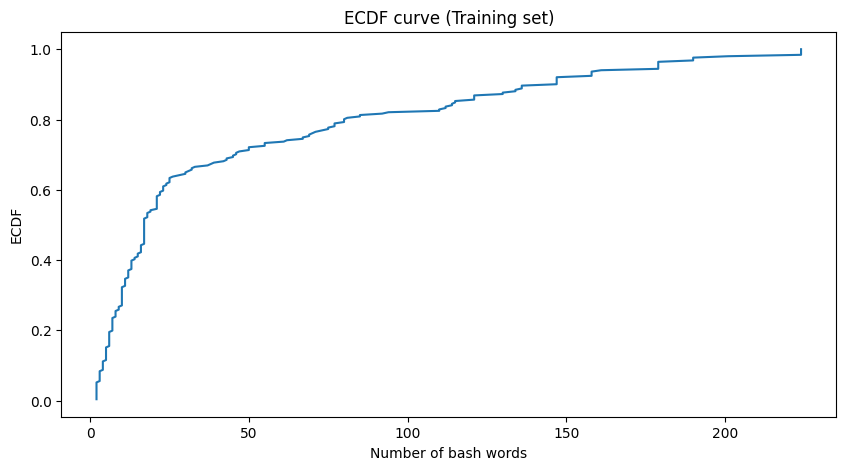

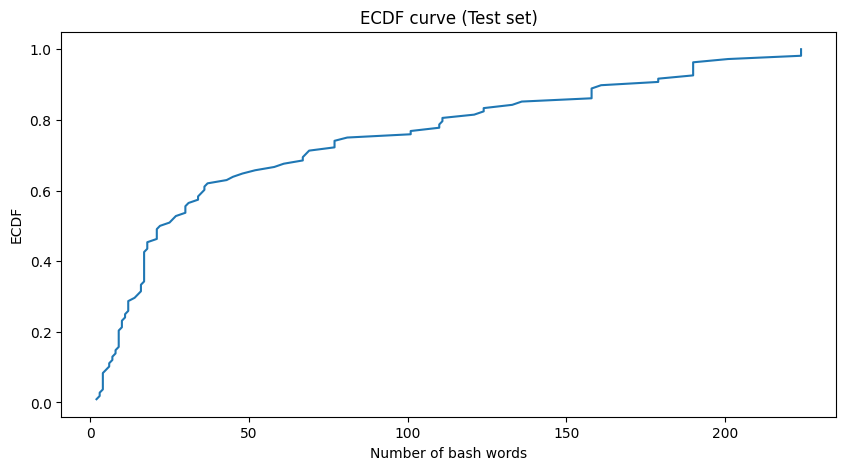

In [93]:
# calculate amount of bash words per each session
train_num_bash_word = [len(s.split(' ')) for s in train_sessions]
test_num_bash_word = [len(s.split(' ')) for s in test_sessions]

print(f"Average Bash words per session in training set: {np.average(train_num_bash_word):.2f}")
print(f"Average Bash words per session in test set: {np.average(test_num_bash_word):.2f}")

plot_ecdf("ECDF curve (Training set)", train_num_bash_word, x_label="Number of bash words")
plot_ecdf("ECDF curve (Test set)", test_num_bash_word, x_label="Number of bash words")

## 2. Tokenization

### 2.1 Load Tokenizers

In [94]:
# define tokenizer models
bert_model_name = "google-bert/bert-base-uncased"
unixcoder_model_name = "microsoft/unixcoder-base"

In [95]:
# load tokenizers
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
unixcoder_tokenizer = AutoTokenizer.from_pretrained(unixcoder_model_name, use_fast=True, add_prefix_space=True)

In [96]:
# tokenize given ssh commands
commands = ['cat', 'shell', 'echo', 'top', 'chpasswd', 'crontab', 'wget', 'busybox', 'grep']

bert_tokenized_comms = bert_tokenizer(commands)
unixcoder_tokenized_comms = unixcoder_tokenizer(commands)

print(f"BERT tokenized:\n{bert_tokenized_comms}\n\n")
print(f"UnixCoder tokenized:\n{unixcoder_tokenized_comms}")

BERT tokenized:
{'input_ids': [[101, 4937, 102], [101, 5806, 102], [101, 9052, 102], [101, 2327, 102], [101, 10381, 15194, 21724, 102], [101, 13675, 12162, 7875, 102], [101, 1059, 18150, 102], [101, 5697, 8758, 102], [101, 24665, 13699, 102]], 'token_type_ids': [[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], 'attention_mask': [[1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]]}


UnixCoder tokenized:
{'input_ids': [[0, 14512, 2], [0, 10171, 2], [0, 5403, 2], [0, 3194, 2], [0, 733, 21073, 2], [0, 404, 6391, 514, 2], [0, 477, 459, 2], [0, 17930, 1849, 2], [0, 36378, 2]], 'attention_mask': [[1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1]]}


It depends on the tokenizer. The BERT tokenizer uses WordPiece encoding, for example: `'token','##izer'`. while Unixcoder uses BytePair Encoding (BPE), for example: `'token','izer'`. They are both processes **bottom-up**, which means starts form characters, picks most frequent (BERT) or informative (Unixcoder) combinations. The main difference on ratio related on how tokenizers convert non-representable inputs, for example: on BERT case, unknown inputs assigned as `[UNK]` token, which leads information lost, while Unixcoder first convert to byte pair preserving any data, which can increase tokens amount.

In [97]:
# average ratio
ratio_bert = sum( len(ids) for ids in bert_tokenized_comms['input_ids'] ) / len(commands)
ratio_unixcoder = sum( len(ids) for ids in unixcoder_tokenized_comms['input_ids'] ) / len(commands)

print(f"Ratio BERT: {ratio_bert:.2f}")
print(f"Ratio UnixCoder: {ratio_unixcoder:.2f}")

Ratio BERT: 3.78
Ratio UnixCoder: 3.56


### 2.2 Tokenize training set

In [98]:
# tokenize training set
train_bert_tokenized = [bert_tokenizer(session) for session in train_sessions]
train_unixcoder_tokenized = [unixcoder_tokenizer(session) for session in train_sessions]

Token indices sequence length is longer than the specified maximum sequence length for this model (1889 > 512). Running this sequence through the model will result in indexing errors


In [99]:
# average bert token
train_bert_n_tokens = [len(i['input_ids']) for i in train_bert_tokenized]   # per session
avg_bert = int(sum(train_bert_n_tokens) / len(train_bert_tokenized))

# average unixcoder token
train_unixcoder_n_tokens = [len(i['input_ids']) for i in train_unixcoder_tokenized]   # per session
avg_unixcoder = int(sum(train_unixcoder_n_tokens) / len(train_unixcoder_tokenized))

print(f"Average token by BERT: {avg_bert}")
print(f"Average token by UnixCoder: {avg_unixcoder}\n")

# maximum token per model
max_bert = max(train_bert_n_tokens)
max_unixcoder= max(train_unixcoder_n_tokens)

print(f"Maximum token by BERT: {max_bert}")
print(f"Maximum token by UnixCoder: {max_unixcoder}")

Average token by BERT: 178
Average token by UnixCoder: 409

Maximum token by BERT: 1889
Maximum token by UnixCoder: 28920


Unixcoder generates more tokens on average because unlike BERT, it never collapses unknown SSH words into `[UNK]`, instead always splitting them into subpieces via BPE.

In [100]:
# number of sessions, which truncated
max_length = 512

truncated_n_bert = len([1 for i in train_bert_n_tokens if i > max_length])
truncated_n_unixcoder = len([1 for i in train_unixcoder_n_tokens if i > max_length])

print(f"Number of session to be truncated by BERT: {truncated_n_bert}")
print(f"Number of session to be truncated by UnixCoder: {truncated_n_unixcoder}")

Number of session to be truncated by BERT: 24
Number of session to be truncated by UnixCoder: 29


In [101]:
# session with max number of tokens
max_token_ssn_bert = train_sessions[train_bert_n_tokens.index(max_bert)]
max_token_ssn_unixcoder = train_sessions[train_unixcoder_n_tokens.index(max_unixcoder)]

print(f"Number of bash words per session with max number of tokens by BERT: {len(max_token_ssn_bert.split(' '))}")
print(f"Number of bash words per session with max number of tokens by UnixCoder: {len(max_token_ssn_unixcoder.split(' '))}")

Number of bash words per session with max number of tokens by BERT: 134
Number of bash words per session with max number of tokens by UnixCoder: 134


Both tokenizers produce high token counts because bash words are not natural language — they include URLs, base64 encoded strings, and long directory paths, which split into many tokens. BERT produces fewer tokens than Unixcoder because it collapses unknown complex words into a single `[UNK]` token, while Unixcoder always splits them into subpieces.

### 2.3 Truncated Tokenize Training set

In [102]:
# truncate preprocessing
train_trunc_sessions = list()
for session in train_sessions:
    train_trunc_sessions.append(" ".join([i[:30] if len(i) > 30 else i  for i in session.split(' ')]))

In [103]:
# tokenize truncated training set
train_trunc_bert_tokenized = [bert_tokenizer(session) for session in train_trunc_sessions]
train_trunc_unixcoder_tokenized = [unixcoder_tokenizer(session) for session in train_trunc_sessions]

In [104]:
# average bert token after truncation
train_trunc_bert_n_tokens = [len(i['input_ids']) for i in train_trunc_bert_tokenized]   # per session
avg_trunc_bert = int(sum(train_trunc_bert_n_tokens) / len(train_trunc_bert_tokenized))

# average unixcoder token after truncation
train_trunc_unixcoder_n_tokens = [len(i['input_ids']) for i in train_trunc_unixcoder_tokenized]   # per session
avg_trunc_unixcoder = int(sum(train_trunc_unixcoder_n_tokens) / len(train_trunc_unixcoder_tokenized))

print(f"Average token after truncation by BERT: {avg_trunc_bert}")
print(f"Average token after truncation by UnixCoder: {avg_trunc_unixcoder}\n")

# maximum token per model
max_trunc_bert = max(train_trunc_bert_n_tokens)
max_trunc_unixcoder= max(train_trunc_unixcoder_n_tokens)

print(f"Maximum token by BERT: {max_trunc_bert}")
print(f"Maximum token by UnixCoder: {max_trunc_unixcoder}")

Average token after truncation by BERT: 128
Average token after truncation by UnixCoder: 110

Maximum token by BERT: 920
Maximum token by UnixCoder: 824


In [105]:
# number of words per session
train_trunc_n_words = [len(i.split(' ')) for i in train_trunc_sessions]

In [106]:
# ratio per each model
ratio_bert = [token/word for token, word in zip(train_trunc_bert_n_tokens, train_trunc_n_words)]
ratio_unixcoder = [token/word for token, word in zip(train_trunc_unixcoder_n_tokens, train_trunc_n_words)]

avg_ratio_bert = sum(ratio_bert) / len(ratio_bert)
avg_ratio_unixcoder = sum(ratio_unixcoder) / len(ratio_unixcoder)

print(f"Average ratio by BERT: {avg_ratio_bert:.2f}")
print(f"Average ratio by UnixCoder: {avg_ratio_unixcoder:.2f}")

Average ratio by BERT: 3.23
Average ratio by UnixCoder: 2.77


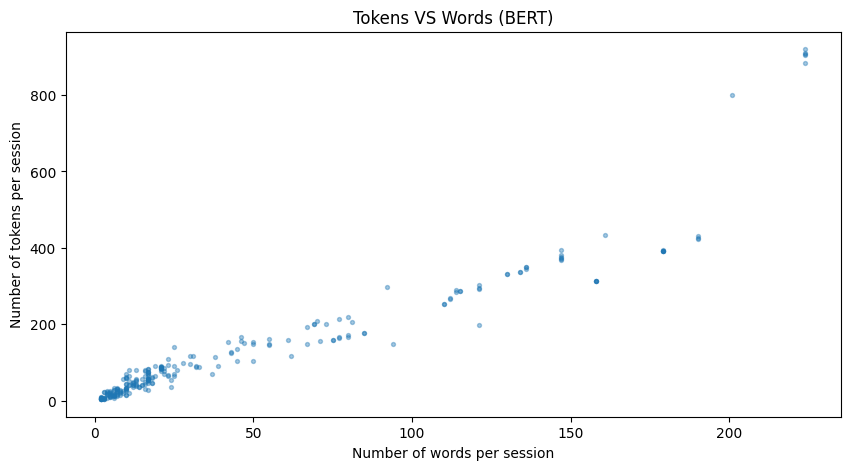

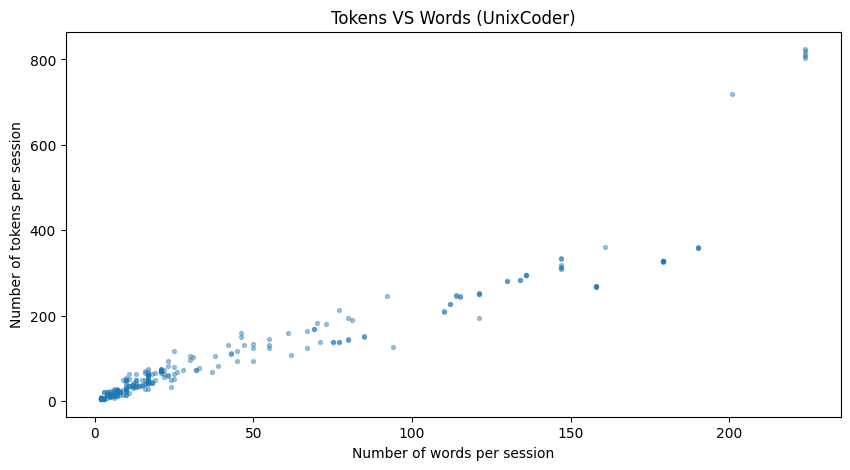

In [107]:
# plot ratio curve
plot_scatter_ratio("Tokens VS Words (BERT)", train_trunc_n_words, train_trunc_bert_n_tokens)
plot_scatter_ratio("Tokens VS Words (UnixCoder)", train_trunc_n_words, train_trunc_unixcoder_n_tokens)

In [108]:
# number of sessions, which truncated after truncation
truncated_n2_bert = len([1 for i in train_trunc_bert_n_tokens if i > max_length])
truncated_n2_unixcoder = len([1 for i in train_trunc_unixcoder_n_tokens if i > max_length])

print(f"Number of session to be truncated by BERT: {truncated_n2_bert}")
print(f"Number of session to be truncated by UnixCoder: {truncated_n2_unixcoder}")

Number of session to be truncated by BERT: 6
Number of session to be truncated by UnixCoder: 6


## 3. Model Training

### 3.1 Preprocessing

In [109]:
# split to training and validation set
train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['label'].apply(lambda x: max(set(x), key=x.count)))
test_df = df_test.copy()

In [110]:
# map labels to id, number of unique tags
id2label = {i:l for i, l in enumerate(unique_tags)}
label2id = {l:i for i, l in enumerate(unique_tags)}
num_labels = len(unique_tags)

In [111]:
# extracting words and tag for each set
train_words, train_tags = get_words_tags_pair(train_df)
val_words, val_tags = get_words_tags_pair(val_df)
test_words, test_tags = get_words_tags_pair(test_df)

In [112]:
# tokenize training, val, test sets
bert_train_words_tokenized = bert_tokenizer(train_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)
bert_val_words_tokenized = bert_tokenizer(val_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)
bert_test_words_tokenized = bert_tokenizer(test_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)

unixcoder_train_words_tokenized = unixcoder_tokenizer(train_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)
unixcoder_val_words_tokenized = unixcoder_tokenizer(val_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)
unixcoder_test_words_tokenized = unixcoder_tokenizer(test_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)

In [113]:
# word-level to token-level
bert_train_words_tokenized['labels'] = aligner(train_words, train_tags, bert_train_words_tokenized, label2id)
bert_val_words_tokenized['labels'] = aligner(val_words, val_tags, bert_val_words_tokenized, label2id)
bert_test_words_tokenized['labels'] = aligner(test_words, test_tags, bert_test_words_tokenized, label2id)

unixcoder_train_words_tokenized['labels'] = aligner(train_words, train_tags, unixcoder_train_words_tokenized, label2id)
unixcoder_val_words_tokenized['labels'] = aligner(val_words, val_tags, unixcoder_val_words_tokenized, label2id)
unixcoder_test_words_tokenized['labels'] = aligner(test_words, test_tags, unixcoder_test_words_tokenized, label2id)

In [114]:
# from batch_encoding to dict converter function
def be2dict(tokenized)-> dict: return {k: tokenized[k] for k in tokenized}

In [115]:
# convert the Batch Encoding into a HuggingFace DataSet
bert_train_dataset = HFDataset.from_dict(be2dict(bert_train_words_tokenized))
bert_val_dataset = HFDataset.from_dict(be2dict(bert_val_words_tokenized))
bert_test_dataset = HFDataset.from_dict(be2dict(bert_test_words_tokenized))

unixcoder_train_dataset = HFDataset.from_dict(be2dict(unixcoder_train_words_tokenized))
unixcoder_val_dataset = HFDataset.from_dict(be2dict(unixcoder_val_words_tokenized))
unixcoder_test_dataset = HFDataset.from_dict(be2dict(unixcoder_test_words_tokenized))

In [116]:
# keep all sets together (optional)
bert_full_dataset = HFDatasetDict({
    'train': bert_train_dataset,
    'validation': bert_val_dataset,
    'test': bert_test_dataset
})

unixcoder_full_dataset = HFDatasetDict({
    'train': unixcoder_train_dataset,
    'validation': unixcoder_val_dataset,
    'test': unixcoder_test_dataset
})

### 3.2 Training Set-up

In [117]:
# define set-up
training_args = TrainingArguments(
    output_dir='../out/fine_tune_cls',
    num_train_epochs=10,
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    warmup_ratio=0.1,

    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='token_f1',
    greater_is_better=True,

    logging_steps=25,
    report_to='none',
    fp16=True,
    gradient_accumulation_steps=2,
)

### 3.3 Fine-Tuning - BERT

#### 3.3.1 BERT pre-trained

In [118]:
# define data collator
data_collator = DataCollatorForTokenClassification(tokenizer=bert_tokenizer)

In [119]:
# load model (BERT)
bert_model = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=bert_model_name,
    id2label=id2label,
    label2id=label2id,
    num_labels=num_labels,
)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [120]:
# train (fine-tuning), evaluate on test set
bert_trainer = get_trainer(bert_model, bert_tokenizer, training_args, bert_train_dataset, bert_val_dataset, data_collator, compute_metrics)
bert_trainer.train()
bert_test_metrics = bert_trainer.evaluate(eval_dataset=bert_test_dataset)

Epoch,Training Loss,Validation Loss,Token Accuracy,Token Precision,Token Recall,Token F1,Avg Fidelity,F1 Impact,F1 Discovery,F1 Persistence,F1 Not malicious yet,F1 Defense evasion,F1 Execution,F1 Other
1,No log,0.985964,0.695711,0.348547,0.263796,0.239866,0.565998,0.000000,0.849150,0.139154,0.000000,0.000000,0.690758,0.000000
2,1.240600,0.706064,0.789799,0.387426,0.352727,0.350976,0.644672,0.000000,0.886868,0.792966,0.043956,0.000000,0.733040,0.000000
3,1.240600,0.501843,0.842929,0.508279,0.395867,0.397153,0.653674,0.000000,0.927868,0.863531,0.000000,0.000000,0.811460,0.177215
4,0.602300,0.443130,0.872102,0.669139,0.547785,0.584340,0.729179,0.459770,0.945535,0.898021,0.398810,0.000000,0.842790,0.545455
5,0.602300,0.388497,0.892774,0.724550,0.556926,0.605954,0.772373,0.446927,0.949511,0.929217,0.413793,0.000000,0.870650,0.631579
6,0.285900,0.346182,0.904173,0.675406,0.659494,0.665050,0.793531,0.616034,0.959884,0.919575,0.500000,0.000000,0.891643,0.768212
7,0.285900,0.350358,0.909583,0.678284,0.695384,0.681544,0.826855,0.641509,0.957601,0.942836,0.524476,0.000000,0.897158,0.807229
8,0.132600,0.311544,0.909003,0.747876,0.729583,0.725507,0.778270,0.646154,0.968794,0.931113,0.480000,0.386555,0.896701,0.769231
9,0.132600,0.297331,0.925425,0.754084,0.766896,0.756069,0.803325,0.661355,0.981432,0.949178,0.494382,0.446602,0.917431,0.842105
10,0.070900,0.298624,0.926391,0.752803,0.781223,0.761500,0.809374,0.661417,0.982650,0.949178,0.518732,0.410714,0.915722,0.892086


In [121]:
print(f"Accuracy (BERT): {bert_test_metrics['eval_token_accuracy']:.2f}")
print(f"Precision (BERT): {bert_test_metrics['eval_token_precision']:.2f}")
print(f"Recall (BERT): {bert_test_metrics['eval_token_recall']:.2f}")
print(f"F1-Macro (BERT): {bert_test_metrics['eval_token_f1']:.2f}")
print(f"Average fidelity (BERT): {bert_test_metrics['eval_avg_fidelity']:.2f}")

Accuracy (BERT): 0.85
Precision (BERT): 0.82
Recall (BERT): 0.58
F1-Macro (BERT): 0.64
Average fidelity (BERT): 0.83


In [122]:
# compute metrics (BERT)
bert_metric_tags = [i.replace('eval_f1_', '') for i in bert_test_metrics if i.startswith('eval_f1_')]
bert_f1_metrics = [bert_test_metrics[i] * 100 for i in bert_test_metrics if i.startswith('eval_f1_')]

The model ahieve "good" results, but only because it's fine-tuning (pre-trained). The issue is around less known patterns, as BERT tokenizer assigns unknowns as `[UNK]`, it losses usefull patterns. It is clear visible on **'Others'** MITRE tag.

#### 3.3.2 BERT weightless (naked)

In [123]:
# unfortunately my gpu can't take whole data, so we just clear previous model
del bert_trainer
del bert_model

gc.collect()
torch.cuda.empty_cache()

In [124]:
# load config weightless (BERT weightless)
bert_config = AutoConfig.from_pretrained(
    pretrained_model_name_or_path=bert_model_name,
    id2label=id2label,
    label2id=label2id,
    num_labels=num_labels,
)

In [125]:
# load model weightless (BERT weightless)
bert_model_wl = AutoModelForTokenClassification.from_config(bert_config)

In [126]:
# train (fine-tuning), evaluate on test set
bert_trainer_wl = get_trainer(bert_model_wl, bert_tokenizer, training_args, bert_train_dataset, bert_val_dataset, data_collator, compute_metrics)
bert_trainer_wl.train()
bert_test_wl_metrics = bert_trainer_wl.evaluate(eval_dataset=bert_test_dataset)

Epoch,Training Loss,Validation Loss,Token Accuracy,Token Precision,Token Recall,Token F1,Avg Fidelity,F1 Impact,F1 Discovery,F1 Persistence,F1 Not malicious yet,F1 Defense evasion,F1 Execution,F1 Other
1,No log,1.119321,0.660549,0.191503,0.231033,0.207249,0.568117,0.000000,0.766568,0.000000,0.000000,0.000000,0.684178,0.000000
2,1.494700,1.576135,0.552743,0.239975,0.178444,0.154649,0.388154,0.000000,0.683185,0.008646,0.000000,0.000000,0.390716,0.000000
3,1.494700,0.983196,0.740726,0.429792,0.315808,0.320590,0.628551,0.015748,0.838647,0.554913,0.094787,0.000000,0.740038,0.000000
4,1.181700,0.895438,0.733385,0.321374,0.315901,0.314264,0.567270,0.000000,0.813424,0.689711,0.000000,0.000000,0.696713,0.000000
5,1.181700,0.827744,0.751159,0.468635,0.319127,0.321916,0.611953,0.046875,0.838909,0.629991,0.000000,0.000000,0.737636,0.000000
6,0.874900,0.705030,0.770479,0.636320,0.487652,0.480361,0.630553,0.339921,0.865497,0.728882,0.187793,0.139535,0.738833,0.362069
7,0.874900,0.647639,0.790765,0.730989,0.417701,0.461378,0.658050,0.240000,0.875612,0.738340,0.126316,0.250000,0.766819,0.232558
8,0.714200,0.627289,0.800811,0.640004,0.548213,0.548895,0.668272,0.285714,0.875311,0.751623,0.386207,0.212766,0.801235,0.529412
9,0.714200,0.641368,0.803516,0.756725,0.459937,0.502883,0.668513,0.134328,0.883226,0.753414,0.248889,0.212766,0.787559,0.500000
10,0.562400,0.581694,0.812983,0.723040,0.553800,0.581229,0.714232,0.287582,0.886777,0.753404,0.453674,0.250000,0.801404,0.635762


In [127]:
print(f"Accuracy (BERT weightless): {bert_test_wl_metrics['eval_token_accuracy']:.2f}")
print(f"Precision (BERT weightless): {bert_test_wl_metrics['eval_token_precision']:.2f}")
print(f"Recall (BERT weightless): {bert_test_wl_metrics['eval_token_recall']:.2f}")
print(f"F1-Macro (BERT weightless): {bert_test_wl_metrics['eval_token_f1']:.2f}")
print(f"Average fidelity (BERT weightless): {bert_test_wl_metrics['eval_avg_fidelity']:.2f}")

Accuracy (BERT weightless): 0.73
Precision (BERT weightless): 0.59
Recall (BERT weightless): 0.42
F1-Macro (BERT weightless): 0.45
Average fidelity (BERT weightless): 0.71


In [128]:
# compute metrics (BERT weightless)
bert_wl_metric_tags = [i.replace('eval_f1_', '') for i in bert_test_wl_metrics if i.startswith('eval_f1_')]
bert_wl_f1_metrics = [bert_test_wl_metrics[i] * 100 for i in bert_test_wl_metrics if i.startswith('eval_f1_')]

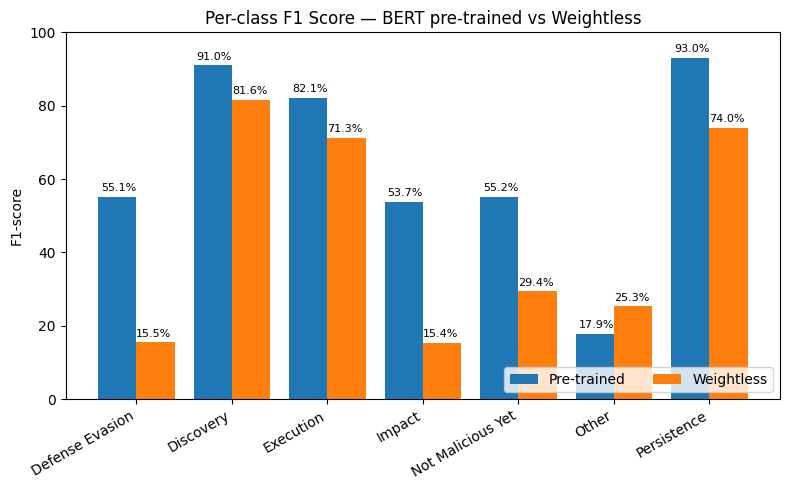

In [129]:
bert_f1_metrics_dict = {k: v for k, v in zip(unique_tags, bert_f1_metrics)}
bert_wl_f1_metrics_dict = {k: v for k, v in zip(unique_tags, bert_wl_f1_metrics)}
plot_bars("Per-class F1 Score — BERT pre-trained vs Weightless", bert_f1_metrics_dict, bert_wl_f1_metrics_dict, ("Pre-trained", "Weightless"), "F1-score", 100)

In [130]:
metrics_table = pd.DataFrame({
    "Metrics": ["Accuracy", "Precision", "Recall", "F1-Macro", "Avg Fidelity"],
    "pre-trained (BERT)": [
        bert_test_metrics['eval_token_accuracy'],
        bert_test_metrics['eval_token_precision'],
        bert_test_metrics['eval_token_recall'],
        bert_test_metrics['eval_token_f1'],
        bert_test_metrics['eval_avg_fidelity']
    ],
    "weightless (BERT)": [
        bert_test_wl_metrics['eval_token_accuracy'],
        bert_test_wl_metrics['eval_token_precision'],
        bert_test_wl_metrics['eval_token_recall'],
        bert_test_wl_metrics['eval_token_f1'],
        bert_test_wl_metrics['eval_avg_fidelity']
    ]
}).set_index("Metrics")
metrics_table = metrics_table.round(2)
metrics_table.style.format("{:.2f}").set_caption("Metrics Comparison: pretrain vs weightless")
metrics_table

,pre-trained (BERT),weightless (BERT)
Metrics,,
Accuracy,0.85,0.73
Precision,0.82,0.59
Recall,0.58,0.42
F1-Macro,0.64,0.45
Avg Fidelity,0.83,0.71


The dataset is too small for classification from random weights. Except majority classes, it cannot predict middle and minority classes, which is shown on bar.

### 3.4 Fine-Tuning - UnixCoder

In [131]:
# unfortunately my gpu can't take whole data, so we just clear previous model
del bert_trainer_wl
del bert_model_wl

gc.collect()
torch.cuda.empty_cache()

In [132]:
# define data collator
data_collator = DataCollatorForTokenClassification(tokenizer=unixcoder_tokenizer)

In [133]:
# load model (UnixCoder)
unixcoder_model = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=unixcoder_model_name,
    id2label=id2label,
    label2id=label2id,
    num_labels=num_labels,
)

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [134]:
# train (fine-tuning), evaluate on test set
unixcoder_trainer = get_trainer(unixcoder_model, unixcoder_tokenizer, training_args, unixcoder_train_dataset, unixcoder_val_dataset, data_collator, compute_metrics)
unixcoder_trainer.train()
unixcoder_test_metrics = unixcoder_trainer.evaluate(eval_dataset=unixcoder_test_dataset)

Epoch,Training Loss,Validation Loss,Token Accuracy,Token Precision,Token Recall,Token F1,Avg Fidelity,F1 Impact,F1 Discovery,F1 Persistence,F1 Not malicious yet,F1 Defense evasion,F1 Execution,F1 Other
1,No log,0.846047,0.700430,0.389315,0.258153,0.229382,0.575327,0.017857,0.825576,0.020236,0.013423,0.000000,0.728584,0.000000
2,1.295600,0.542401,0.817771,0.562924,0.375743,0.389266,0.644008,0.087719,0.893617,0.764933,0.107143,0.000000,0.816655,0.054795
3,1.295600,0.411514,0.883789,0.692769,0.658458,0.659734,0.737244,0.564516,0.949457,0.906644,0.366972,0.600000,0.868847,0.361702
4,0.417200,0.468129,0.877685,0.630317,0.688763,0.635934,0.719214,0.587361,0.948992,0.938811,0.470255,0.454545,0.861101,0.190476
5,0.417200,0.474293,0.881754,0.723327,0.690627,0.671054,0.757477,0.702703,0.938978,0.930828,0.486239,0.421053,0.849765,0.367816
6,0.164600,0.440768,0.904364,0.759175,0.785499,0.762342,0.778349,0.671937,0.956147,0.923077,0.634483,0.553191,0.887278,0.710280
7,0.164600,0.389128,0.908207,0.807993,0.715776,0.725655,0.807304,0.619469,0.952606,0.909548,0.736434,0.551724,0.904745,0.405063
8,0.056500,0.360573,0.919286,0.789146,0.785159,0.759103,0.812175,0.638298,0.973647,0.903494,0.693141,0.561404,0.913303,0.630435
9,0.056500,0.378282,0.918381,0.808643,0.787653,0.784727,0.837764,0.658120,0.962718,0.910008,0.753968,0.536082,0.910289,0.761905
10,0.032900,0.406750,0.912503,0.792199,0.772127,0.766788,0.823812,0.655319,0.957362,0.915254,0.730769,0.525253,0.903557,0.680000


In [135]:
print(f"Accuracy (UnixCoder): {unixcoder_test_metrics['eval_token_accuracy']:.2f}")
print(f"Precision (UnixCoder): {unixcoder_test_metrics['eval_token_precision']:.2f}")
print(f"Recall (UnixCoder): {unixcoder_test_metrics['eval_token_recall']:.2f}")
print(f"F1-Macro (UnixCoder): {unixcoder_test_metrics['eval_token_f1']:.2f}")
print(f"Average fidelity (UnixCoder): {unixcoder_test_metrics['eval_avg_fidelity']:.2f}")

Accuracy (UnixCoder): 0.87
Precision (UnixCoder): 0.76
Recall (UnixCoder): 0.69
F1-Macro (UnixCoder): 0.72
Average fidelity (UnixCoder): 0.87


In [136]:
# metrics compute (UnixCoder)
unixcoder_metric_tags = [i.replace('eval_f1_', '') for i in unixcoder_test_metrics if i.startswith('eval_f1_')]
unixcoder_f1_metrics = [unixcoder_test_metrics[i] * 100 for i in unixcoder_test_metrics if i.startswith('eval_f1_')]

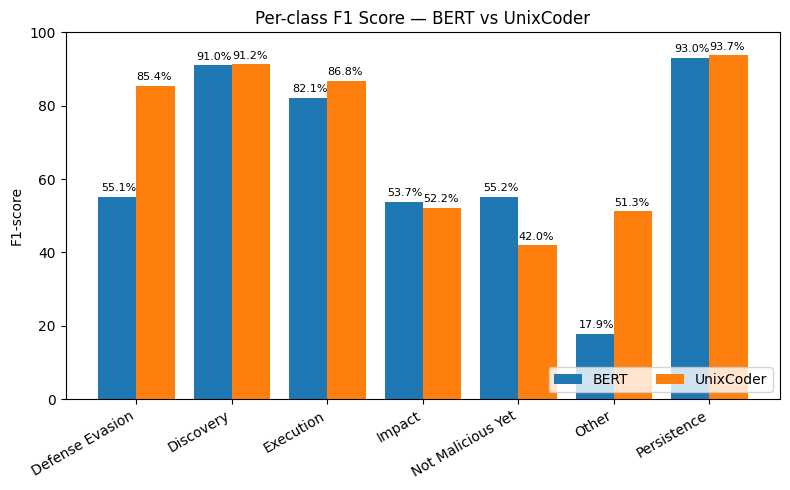

In [137]:
bert_f1_metrics_dict = {k: v for k, v in zip(unique_tags, bert_f1_metrics)}
unixcoder_f1_metrics_dict = {k: v for k, v in zip(unique_tags, unixcoder_f1_metrics)}
plot_bars("Per-class F1 Score — BERT vs UnixCoder", bert_f1_metrics_dict, unixcoder_f1_metrics_dict, ("BERT", "UnixCoder"), "F1-score", 100)

On imbalanced datasets, F1 is the most representative metric. Since Unixcoder has higher macro F1, the hypothesis is confirmed. BERT's higher Precision simply means it is more conservative in predictions, but overall Unixcoder performs better.

In [138]:
# save model for inference
unixcoder_trainer.save_model("../out/best_model_tokcls")
unixcoder_tokenizer.save_pretrained("../out/best_model_tokcls")

('../out/best_model_tokcls/tokenizer_config.json',
 '../out/best_model_tokcls/special_tokens_map.json',
 '../out/best_model_tokcls/vocab.json',
 '../out/best_model_tokcls/merges.txt',
 '../out/best_model_tokcls/added_tokens.json',
 '../out/best_model_tokcls/tokenizer.json')

### 3.5 Frozen Fine-Tuning

#### 3.5.1 Last 2 Encoders and Classification Head

In [139]:
# unfortunately my gpu can't take whole data, so we just clear previous model
del unixcoder_trainer
del unixcoder_model

gc.collect()
torch.cuda.empty_cache()

In [140]:
# load model (Frozen Model)
frozen_model = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=unixcoder_model_name,
    id2label=id2label,
    label2id=label2id,
    num_labels=num_labels,
)

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [141]:
# freeze all layers
for param in frozen_model.base_model.parameters():
    param.requires_grad = False

# unfreeze the last 2 layers
for param in frozen_model.base_model.encoder.layer[-2:].parameters():
    param.requires_grad = True

# unfreeze the classification head
for param in frozen_model.classifier.parameters():
    param.requires_grad = True

In [142]:
# total number of parameters
total_params = sum(p.numel() for p in frozen_model.parameters())
print(f"Total number of parameters: {total_params}")

# number of parameters to train
num_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
print(f"Number of parameters to train: {num_params}")

Total number of parameters: 125344519
Number of parameters to train: 14181127


In [143]:
# train (fine-tuning), evaluate on test set
frozen_trainer = get_trainer(frozen_model, unixcoder_tokenizer, training_args, unixcoder_train_dataset, unixcoder_val_dataset, data_collator, compute_metrics)
frozen_trainer.train()
frozen_test_metrics = frozen_trainer.evaluate(eval_dataset=unixcoder_test_dataset)

Epoch,Training Loss,Validation Loss,Token Accuracy,Token Precision,Token Recall,Token F1,Avg Fidelity,F1 Impact,F1 Discovery,F1 Persistence,F1 Not malicious yet,F1 Defense evasion,F1 Execution,F1 Other
1,No log,1.072276,0.673977,0.336347,0.244993,0.218306,0.538439,0.018349,0.771855,0.000000,0.000000,0.000000,0.737938,0.000000
2,1.509900,0.811481,0.688673,0.434555,0.262971,0.254613,0.561804,0.068376,0.783557,0.191358,0.013333,0.000000,0.725669,0.000000
3,1.509900,0.667467,0.768257,0.517141,0.362924,0.384400,0.614555,0.115702,0.851543,0.689093,0.219895,0.000000,0.758231,0.056338
4,0.763100,0.631703,0.790188,0.481705,0.492180,0.476855,0.661643,0.600000,0.877762,0.710714,0.336996,0.000000,0.784342,0.028169
5,0.763100,0.577323,0.805562,0.551960,0.440309,0.464770,0.676963,0.300000,0.874826,0.739593,0.473684,0.000000,0.809730,0.055556
6,0.535800,0.538148,0.817771,0.622163,0.467009,0.503690,0.689312,0.331126,0.886035,0.777046,0.493927,0.088889,0.813673,0.135135
7,0.535800,0.529679,0.829754,0.626297,0.543713,0.563757,0.711192,0.567797,0.901904,0.792706,0.521073,0.075472,0.819054,0.268293
8,0.452200,0.502373,0.834954,0.653998,0.544558,0.571115,0.714395,0.532110,0.907958,0.815884,0.536965,0.107143,0.815692,0.282051
9,0.452200,0.499815,0.838571,0.692183,0.593944,0.598092,0.720034,0.507177,0.912729,0.823529,0.542857,0.409639,0.819285,0.171429
10,0.373600,0.507620,0.835632,0.676183,0.566533,0.577175,0.716570,0.495238,0.910959,0.825210,0.542857,0.277778,0.816757,0.171429


In [144]:
print(f"Accuracy (Frozen): {frozen_test_metrics['eval_token_accuracy']:.2f}")
print(f"Precision (Frozen): {frozen_test_metrics['eval_token_precision']:.2f}")
print(f"Recall (Frozen): {frozen_test_metrics['eval_token_recall']:.2f}")
print(f"F1-Macro (Frozen): {frozen_test_metrics['eval_token_f1']:.2f}")
print(f"Average fidelity (Frozen): {frozen_test_metrics['eval_avg_fidelity']:.2f}")

Accuracy (Frozen): 0.79
Precision (Frozen): 0.72
Recall (Frozen): 0.49
F1-Macro (Frozen): 0.53
Average fidelity (Frozen): 0.79


In [145]:
# metrics compute (Frozen)
frozen_metric_tags = [i.replace('eval_f1_', '') for i in frozen_test_metrics if i.startswith('eval_f1_')]
frozen_f1_metrics = [frozen_test_metrics[i] * 100 for i in frozen_test_metrics if i.startswith('eval_f1_')]

#### 3.5.2 Classification Head only

In [146]:
# unfortunately my gpu can't take whole data, so we just clear previous model
del frozen_trainer
del frozen_model

gc.collect()
torch.cuda.empty_cache()

In [147]:
# load model (Class Head only Model)
head_model = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=unixcoder_model_name,
    id2label=id2label,
    label2id=label2id,
    num_labels=num_labels,
)

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [148]:
# freeze all layers
for param in head_model.base_model.parameters():
    param.requires_grad = False

# unfreeze the classification head
for param in head_model.classifier.parameters():
    param.requires_grad = True

In [149]:
# total number of parameters
total_params = sum(p.numel() for p in head_model.parameters())
print(f"Total number of parameters: {total_params}")

# number of parameters to train
num_params = sum(p.numel() for p in head_model.parameters() if p.requires_grad)
print(f"Number of parameters to train: {num_params}")

Total number of parameters: 125344519
Number of parameters to train: 5383


In [150]:
# train (fine-tuning), evaluate on test set
head_trainer = get_trainer(head_model, unixcoder_tokenizer, training_args, unixcoder_train_dataset, unixcoder_val_dataset, data_collator, compute_metrics, lr=1e-4)
head_trainer.train()
head_test_metrics = head_trainer.evaluate(eval_dataset=unixcoder_test_dataset)

Epoch,Training Loss,Validation Loss,Token Accuracy,Token Precision,Token Recall,Token F1,Avg Fidelity,F1 Impact,F1 Discovery,F1 Persistence,F1 Not malicious yet,F1 Defense evasion,F1 Execution,F1 Other
1,No log,1.847190,0.288944,0.139594,0.123480,0.126675,0.199882,0.038217,0.471737,0.137457,0.010363,0.000000,0.219428,0.009524
2,2.089400,1.451359,0.513452,0.199374,0.186386,0.181300,0.327412,0.057143,0.682110,0.089686,0.010256,0.000000,0.413642,0.016260
3,2.089400,1.265769,0.576758,0.232155,0.208495,0.202677,0.389332,0.044776,0.707298,0.100490,0.012500,0.000000,0.553677,0.000000
4,1.573800,1.155154,0.612706,0.253441,0.224346,0.217524,0.431616,0.046512,0.723694,0.100000,0.012903,0.000000,0.639558,0.000000
5,1.573800,1.085497,0.637124,0.264502,0.234987,0.226434,0.464379,0.047619,0.738474,0.094488,0.012987,0.000000,0.691469,0.000000
6,1.313400,1.039142,0.647298,0.280032,0.242114,0.234786,0.478384,0.047619,0.745058,0.130268,0.013158,0.000000,0.707398,0.000000
7,1.313400,1.010330,0.654081,0.276567,0.245584,0.237840,0.490080,0.047244,0.750509,0.136598,0.012987,0.000000,0.717541,0.000000
8,1.304800,0.989931,0.660864,0.288592,0.250219,0.243191,0.499275,0.047244,0.755027,0.159898,0.013158,0.000000,0.727013,0.000000
9,1.304800,0.978879,0.665612,0.294423,0.254163,0.248189,0.507275,0.062500,0.758606,0.169406,0.013072,0.000000,0.733736,0.000000
10,1.182300,0.975710,0.665385,0.294389,0.254026,0.248089,0.507008,0.062500,0.758550,0.169406,0.013072,0.000000,0.733096,0.000000


In [151]:
print(f"Accuracy (Class Head only): {head_test_metrics['eval_token_accuracy']:.2f}")
print(f"Precision (Class Head only): {head_test_metrics['eval_token_precision']:.2f}")
print(f"Recall (Class Head only): {head_test_metrics['eval_token_recall']:.2f}")
print(f"F1-Macro (Class Head only): {head_test_metrics['eval_token_f1']:.2f}")
print(f"Average fidelity (Class Head only): {head_test_metrics['eval_avg_fidelity']:.2f}")

Accuracy (Class Head only): 0.59
Precision (Class Head only): 0.22
Recall (Class Head only): 0.24
F1-Macro (Class Head only): 0.22
Average fidelity (Class Head only): 0.56


In [152]:
# metrics compute (Class Head only)
head_metric_tags = [i.replace('eval_f1_', '') for i in head_test_metrics if i.startswith('eval_f1_')]
head_f1_metrics = [head_test_metrics[i] * 100 for i in head_test_metrics if i.startswith('eval_f1_')]

Training is faster due to fewer parameters. LR was set higher for the classification head since it starts from random weights and needs to learn faster. In terms of F1-score compared to full fine-tuned Unixcoder: freezing last 2 encoders + head loses ~26.4%, while freezing everything except head loses ~69.4%.

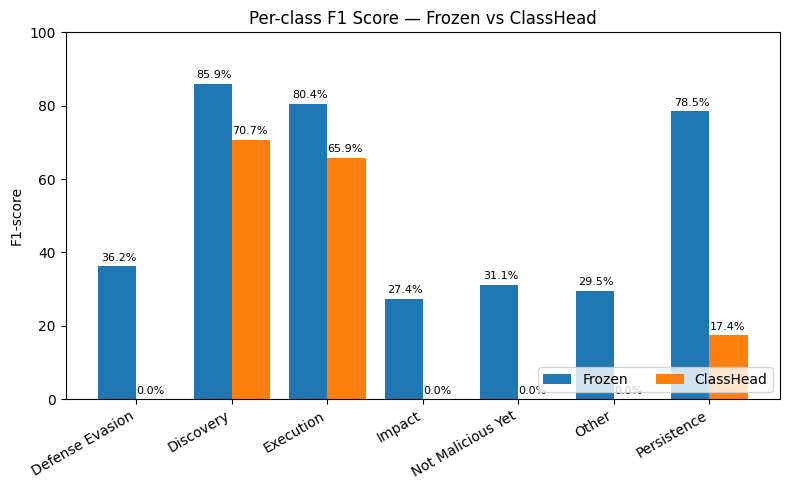

In [153]:
frozen_f1_metrics_dict = {k: v for k, v in zip(unique_tags, frozen_f1_metrics)}
head_f1_metrics_dict = {k: v for k, v in zip(unique_tags, head_f1_metrics)}
plot_bars("Per-class F1 Score — Frozen vs ClassHead", frozen_f1_metrics_dict, head_f1_metrics_dict, ("Frozen", "ClassHead"), "F1-score", 100)

### 3.6 Analysis

In [168]:
# unified metrics comparison table across all 5 models
unified_metrics_table = pd.DataFrame({
    "Model": [
        "BERT (pre-trained)",
        "BERT (weightless)",
        "UnixCoder (pre-trained)",
        "UnixCoder (frozen last 2 + head)",
        "UnixCoder (head only)",
    ],
    "Accuracy": [
        bert_test_metrics['eval_token_accuracy'],
        bert_test_wl_metrics['eval_token_accuracy'],
        unixcoder_test_metrics['eval_token_accuracy'],
        frozen_test_metrics['eval_token_accuracy'],
        head_test_metrics['eval_token_accuracy'],
    ],
    "Precision": [
        bert_test_metrics['eval_token_precision'],
        bert_test_wl_metrics['eval_token_precision'],
        unixcoder_test_metrics['eval_token_precision'],
        frozen_test_metrics['eval_token_precision'],
        head_test_metrics['eval_token_precision'],
    ],
    "Recall": [
        bert_test_metrics['eval_token_recall'],
        bert_test_wl_metrics['eval_token_recall'],
        unixcoder_test_metrics['eval_token_recall'],
        frozen_test_metrics['eval_token_recall'],
        head_test_metrics['eval_token_recall'],
    ],
    "F1-Macro": [
        bert_test_metrics['eval_token_f1'],
        bert_test_wl_metrics['eval_token_f1'],
        unixcoder_test_metrics['eval_token_f1'],
        frozen_test_metrics['eval_token_f1'],
        head_test_metrics['eval_token_f1'],
    ],
    "Avg Fidelity": [
        bert_test_metrics['eval_avg_fidelity'],
        bert_test_wl_metrics['eval_avg_fidelity'],
        unixcoder_test_metrics['eval_avg_fidelity'],
        frozen_test_metrics['eval_avg_fidelity'],
        head_test_metrics['eval_avg_fidelity'],
    ],
}).set_index("Model").round(2)

unified_metrics_table.style.format("{:.2f}").set_caption("Metrics Comparison — All Models")
unified_metrics_table

,Accuracy,Precision,Recall,F1-Macro,Avg Fidelity
Model,,,,,
BERT (pre-trained),0.85,0.82,0.58,0.64,0.83
BERT (weightless),0.73,0.59,0.42,0.45,0.71
UnixCoder (pre-trained),0.87,0.76,0.69,0.72,0.87
UnixCoder (frozen last 2 + head),0.79,0.72,0.49,0.53,0.79
UnixCoder (head only),0.59,0.22,0.24,0.22,0.56


## 4. Inference

### 4.1 Train

In [154]:
# define set-up
testing_args = TrainingArguments(
    output_dir='../out/inference_cls',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    greater_is_better=True,

    logging_steps=25,
    report_to='none',
    fp16=False,
    gradient_accumulation_steps=2,
)

In [155]:
# load best model, tokenizer
model = AutoModelForTokenClassification.from_pretrained("../out/best_model_tokcls")
tokenizer = AutoTokenizer.from_pretrained("../out/best_model_tokcls")

# load trainer
trainer = Trainer(
    model=model,
    args=testing_args,
    train_dataset=None,
    eval_dataset=None,
    processing_class=tokenizer,
    data_collator=data_collator
)

In [156]:
print(f"Num of samples: {df_deploy.shape[0]}")

Num of samples: 174262


In [157]:
# show data sample
print(df_deploy.head())

                                             session  \
0  enable ; system ; shell ; sh ; cat /proc/mount...   
1  enable ; system ; shell ; sh ; cat /proc/mount...   
2  enable ; system ; shell ; sh ; cat /proc/mount...   
3  enable ; system ; shell ; sh ; cat /proc/mount...   
4  enable ; system ; shell ; sh ; cat /proc/mount...   

              timestamps_statements country_name  
0  2019-09-01 00:00:10.493808+00:00       Israel  
1  2019-09-01 00:38:41.134935+00:00       Israel  
2  2019-09-01 00:39:26.263383+00:00       Israel  
3  2019-09-01 00:40:45.132152+00:00       Israel  
4  2019-09-01 00:54:51.783935+00:00       Israel  


In [158]:
# since dataset is large we work with chunks
out_dir = "../out/inference_chunks"
os.makedirs(out_dir, exist_ok=True)

for i in range(0, df_deploy.shape[0], 1000):
    out_path = os.path.join(out_dir, f'preds_{i:06d}.jsonl')

    if os.path.exists(out_path): continue

    df_chunk = df_deploy.iloc[i: i+1000].copy()

    # extracting words
    data_words = get_words(df_chunk)

    # tokenize data words
    words_tokenized = tokenizer(data_words, is_split_into_words=True, padding='max_length', truncation=True, max_length=max_length)

    # convert to huggingface dataset
    words_dataset = HFDataset.from_dict(be2dict(words_tokenized))
    out = trainer.predict(words_dataset)

    logits = out.predictions
    pred_ids = np.argmax(logits, axis=-1)

    pred_word_tags = list()
    for j in range(len(data_words)):
        word_ids = words_tokenized.word_ids(j)
        prev = None
        tags_j = []
        for pos, wid in enumerate(word_ids):
            if wid is None:
                continue
            if wid != prev:  # first subtoken of a word
                tags_j.append(model.config.id2label[int(pred_ids[j][pos])])
                prev = wid
        pred_word_tags.append(tags_j)

    df_out = pd.DataFrame({
        "row_id": df_chunk.index,
        "date": df_chunk["timestamps_statements"].astype(str).str.slice(0, 10),
        "fingerprint": ["|".join(t) for t in pred_word_tags],
        "session": df_chunk["session"].astype(str),  # optional
    })

    df_out.to_json(out_path, orient="records", lines=True)

    # free RAM
    del df_chunk, data_words, words_tokenized, words_dataset, out, logits, pred_ids, pred_word_tags, df_out
    gc.collect()

### 4.2 Analysis

In [159]:
# load predictions from file
all_files = sorted(glob.glob("../out/inference_chunks/preds_*.jsonl"))
df_preds = pd.concat([pd.read_json(f, lines=True) for f in all_files], ignore_index=True)
print(df_preds.head())

   row_id       date                                        fingerprint  \
0       0 2019-09-01  Discovery|Discovery|Discovery|Discovery|Discov...   
1       1 2019-09-01  Discovery|Discovery|Discovery|Discovery|Discov...   
2       2 2019-09-01  Discovery|Discovery|Discovery|Discovery|Discov...   
3       3 2019-09-01  Discovery|Discovery|Discovery|Discovery|Discov...   
4       4 2019-09-01  Discovery|Discovery|Discovery|Discovery|Discov...   

                                             session  
0  enable ; system ; shell ; sh ; cat /proc/mount...  
1  enable ; system ; shell ; sh ; cat /proc/mount...  
2  enable ; system ; shell ; sh ; cat /proc/mount...  
3  enable ; system ; shell ; sh ; cat /proc/mount...  
4  enable ; system ; shell ; sh ; cat /proc/mount...  


In [160]:
# define selected commands
selected_cmd = ['cat', 'grep', 'echo', 'rm']
pred_counts = defaultdict(lambda: defaultdict(int))
examples = dict()

# calculate frequency
for i in df_preds.index:
    words = [ j[:30] if len(j) > 30 else j for j in df_preds.iloc[i]["session"].split() ]
    tags = df_preds.iloc[i]['fingerprint'].split('|')
    if len(words) != len(tags): words = words[:len(tags)]
    for word, tag in zip(words, tags):
        word = word.lower().strip(" ;|&()<>")
        if "/" in word: word = word.split("/")[-1]
        if word in selected_cmd:
            pred_counts[word][tag] += 1
            if (word, tag) not in examples.keys():
                examples[(word, tag)] = df_preds.iloc[i]['session']

In [161]:
# counts tables
pred_counts_table = pd.DataFrame({c: dict(pred_counts.get(c, {})) for c in selected_cmd}).T.fillna(0).astype(int)
pred_counts_table.style.format("{:.2f}").set_caption("COUNTS (FREQUENCY) TABLE:")
pred_counts_table

,Discovery,Execution,Not Malicious Yet,Persistence,Other,Defense Evasion
cat,860900,664,1,0,0,0
grep,995988,0,0,386,0,0
echo,266654,108971,332,387857,2624,0
rm,329286,1397,0,5443,0,8846


**Q:** Are all commands uniquely associated with a single tag?

No, but some commands are relatively near to uniquely associated, for example: `cat` has 99.92% on `Discovery`, only 0.08% on `Execution`, and all other tags 0%, the same with `grep`. While `echo` and `rm` distributed between tags.

In [162]:
# percentage tables
percentage_table = (pred_counts_table.div(pred_counts_table.sum(axis=1), axis=0) * 100).fillna(0).round(2)
percentage_table.style.format("{:.2f}").set_caption("PERCENTAGES TABLE (%):")
percentage_table

,Discovery,Execution,Not Malicious Yet,Persistence,Other,Defense Evasion
cat,99.92,0.08,0.00,0.00,0.00,0.00
grep,99.96,0.00,0.00,0.04,0.00,0.00
echo,34.79,14.22,0.04,50.61,0.34,0.00
rm,95.45,0.40,0.00,1.58,0.00,2.56


In [163]:
# sort examples
examples = {(cmd, tag): session for (cmd, tag), session in sorted(examples.items(), key=lambda x: (x[0][0], x[0][1]))}

# display examples
print("EXAMPLES FOR EACH SELECTED COMMANDS:")
for k, v in examples.items():
    print(f"{k}:\n{v}", end="\n\n")

EXAMPLES FOR EACH SELECTED COMMANDS:
('cat', 'Discovery'):
enable ; system ; shell ; sh ; cat /proc/mounts; /bin/busybox TIPZU ; cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox TIPZU ; tftp; wget; /bin/busybox TIPZU ; dd bs=52 count=1 if=.s || cat .s || while read i; do echo $i; done < .s ; /bin/busybox TIPZU ; rm .s; exit

('cat', 'Execution'):
cat /proc/cpuinfo | grep name | wc -l ; echo -e "admin\nvqckfz14Dsq3\nvqckfz14Dsq3"|passwd|bash ; Enter new UNIX password:  ; echo "admin\nvqckfz14Dsq3\nvqckfz14Dsq3\n"|passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9;}' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "admin admin" > /tmp/up.txt ; rm -rf /var/tmp/dota* ; cat 

In general, yes for majority tags it predicted as it is, while again for minority like `Others` it misclassified, as it is clearly shown on the script.

In [164]:
# sort dataframe by date
df_sorted = df_preds.copy()
df_sorted['date'] = pd.to_datetime(df_sorted['date'])
df_sorted = df_sorted.sort_values(by='date').reset_index(drop=True)

In [165]:
# unique set of fingerprints as dict (key=fp, value: dict(fp_id, date))
unique_fingerprints = dict()
fp2id = dict()  # map dict fp -> id
idx = 0

# extract unique fingerprints and map them to their ids
for i in df_sorted.index:
    if df_sorted.iloc[i]['fingerprint'] not in unique_fingerprints.keys():
        unique_fingerprints[df_sorted.iloc[i]['fingerprint']] = {
            'fingerprint_id': idx,
            'date': df_sorted.iloc[i]['date']
        }
        fp2id[df_sorted.iloc[i]['fingerprint']] = idx
        idx += 1

In [166]:
# add fp_id column
df_sorted['fingerprint_id'] = df_sorted['fingerprint'].map(fp2id)

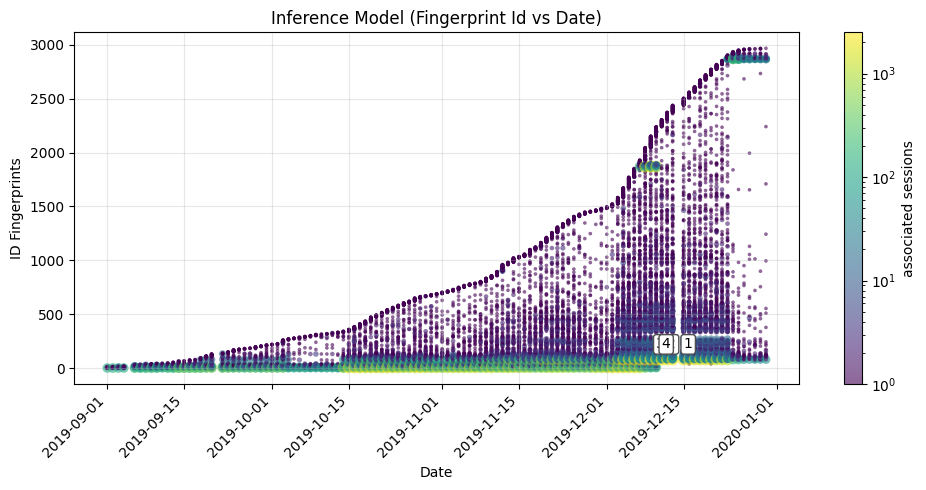

In [167]:
# compute number of sessions per date, fp_id
session_counts = df_sorted.groupby(['date', 'fingerprint_id']).size()
df_session = pd.DataFrame(session_counts.reset_index(name='count'))
plot_scatter_fp("Inference Model (Fingerprint Id vs Date)", df_session['date'].tolist(), df_session['fingerprint_id'].tolist(), df_session['count'].tolist())

The plot provide many use information, for example: fingerprint growth over time, appearance of the same fingerprint across many dates, and discovery of new fingerprints. Yes, there are low fingerprint IDs , which appeared almost all dates. Yes, it is shown by color, brighter colors like yellow, green - indicates high number of associated sessions. Yes, on December it is clearly visible sudden large scale activities with green/yellow color. Also, on first part of December number of new activities increased. For example, Fingerprint ID 0 (first observed 2019-09-01) is dominated by Discovery tactics, representing reconnaissance sessions like `enable ; system ; shell ; sh ; cat /proc/mounts....` Low fingerprint IDs (close to 0) are the most persistent, appearing across almost all dates, suggesting recurring automated attack patterns. High session-count fingerprints (shown in yellow/green) represent large-scale coordinated campaigns, particularly visible in December 2019.